# システム同定

このノートブックでは、MuJoCoの[システム同定](https://en.wikipedia.org/wiki/System_identification)フレームワークについて説明します。システム同定は、シミュレーションが測定値と一致するようにパラメータを最適化します。ここでは、フレームワークの核心概念を紹介し、いくつかの基本的な例を順に見ていきます。より詳細な演習は、今後追加される予定です。

**このノートブックで実施すること:**

1. [**定式化:**](#formulation) sysid問題について簡単に紹介します。
2. [**主要な概念:**](#core-concepts) 質量-ばね-ダンパーの質量を推定します。
3. [**API:**](#api) `Parameter`、`TimeSeries`、`ModelSequences`のような主要なAPI概念を巡ります。
4. [**ロボットアーム:**](#robot-arm) 5-DOFアームの関節アーマチュアを特定し、信頼区間、センサープロット、およびインタラクティブなHTMLレポートを含めます。
5. [**パラメータの識別可能性:**](#ambiguity) パラメータが識別できない場合を理解し、診断します。

---

# System Identification

This notebook demonstrates MuJoCo's [system identification](https://en.wikipedia.org/wiki/System_identification) framework. System identification optimizes parameters so that a simulation matches measured data. We introduce the core concepts of the framework and walk through a few basic examples. More in-depth exercises will be added in the future.

**In this notebook, we will:**

1. [**Formulation:**](#formulation) A brief introduction to the sysid problem.
2. [**Core Concepts:**](#core-concepts) Estimate the mass of a mass-spring-damper.
3. [**API:**](#api) Tour key API concepts, like `Parameter`, `TimeSeries`, and `ModelSequences`.
4. [**Robot Arm:**](#robot-arm) Identify joint armatures for a 5-DOF arm, including confidence intervals, sensor plots, and an interactive HTML report.
5. [**Parameter Identifiability:**](#ambiguity) Understand and diagnose when parameters are unidentifiable.


## セットアップ

---

## Setup


In [ ]:
#@title Install MuJoCo and mediapy
!pip install -q mujoco[sysid] --pre -f https://py.mujoco.org/
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.0 MB/s eta 0:00:00


In [ ]:
#@title Set up GPU rendering
from google.colab import files
import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

In [ ]:
#@title Configure EGL backend
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl


In [ ]:
import mujoco
import mujoco.rollout as rollout
from mujoco import sysid
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
from absl import logging
import base64
from IPython.display import IFrame

logging.set_verbosity("INFO")

def display_report(report):
    html_b64 = base64.b64encode(report.build().encode()).decode()
    return IFrame(src=f"data:text/html;base64,{html_b64}", width="100%", height=800)

<a name="formulation"></a>
# 定式化

---

<a name="formulation"></a>
# Formulation


このライブラリは[**グレーボックス**](https://en.wikipedia.org/wiki/Grey_box_model)識別を実行します。つまり、MuJoCo XMLを介してモデル構造（剛体動力学、接触、アクチュエーター）を提供し、最適化ツールが未知として指定したパラメータを調整します。

ベクトル $\theta$ にまとめられた $K$ 個のパラメータと $N$ 個のセンサー測定値 $y$ が与えられた場合、モデルをシミュレートして予測出力 $\bar y(\theta)$ を生成し、重み付き残差を最小化します。

$$\min_\theta \; \tfrac{1}{2}\lVert W\bigl(\bar y(\theta) - y\bigr)\rVert^2
\qquad \text{s.t.}\quad l \preccurlyeq \theta \preccurlyeq u$$

これは、ボックス制約付きの**非線形最小二乗**問題です。最適化ツールは、有限差分ヤコビアンを用いたガウス・ニュートン/レーベンバーグ・マルカートアルゴリズムを使用します。各パラメータの摂動には独立したシミュレーションロールアウトが必要であり、それらはすべて[`mujoco.rollout`](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/rollout.ipynb)への単一のバッチ呼び出しでCPUスレッド間で並列に実行されます。

基盤となる最適化ツールの詳細については、[最小二乗](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/least_squares.ipynb)ノートブックを参照してください。

---

This library performs [**grey-box**](https://en.wikipedia.org/wiki/Grey_box_model) identification: you provide the model structure (rigid body dynamics, contacts, actuators) via MuJoCo XML, and the optimizer tunes parameters that you specify as unknown.

Given $K$ parameters gathered in a vector $\theta$, and $N$ sensor measurements $y$, we simulate the model to generate a predicted output $\bar y(\theta)$, and minimize a weighted residual:

$$\min_\theta \; \tfrac{1}{2}\lVert W\bigl(\bar y(\theta) - y\bigr)\rVert^2
\qquad \text{s.t.}\quad l \preccurlyeq \theta \preccurlyeq u$$

This is a **nonlinear least-squares** problem with box constraints. The optimizer uses a Gauss-Newton/Levenberg-Marquardt algorithm with finite-difference Jacobians. Each parameter perturbation requires an independent simulation rollout, all of which are executed in parallel across CPU threads in a single batched call to [`mujoco.rollout`](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/rollout.ipynb).

See the [Least Squares](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/least_squares.ipynb) notebook for more details on the underlying optimizer.


<a name="core-concepts"></a>
# 1. 主要な概念

このフレームワークの主要な概念は、アクチュエートされた[質量-ばね-ダンパー](https://en.wikipedia.org/wiki/Mass-spring-damper_model)を用いて説明します。ばねの剛性と減衰は既知ですが、質量を推定する必要があります。

---

<a name="core-concepts"></a>
# 1. Core Concepts

We illustrate the core concepts of this framework using an actuated [mass-spring-damper](https://en.wikipedia.org/wiki/Mass-spring-damper_model). The spring stiffness and damping are known, but we need to estimate the mass.


### モデル

ばねの上に箱があり、力アクチュエータによって駆動され、位置センサーと速度センサーを備えています。真の質量は**1.0 kg**です。

---

### Model

There is a box on a spring, actuated by a force actuator, with position and velocity sensors. The true mass is **1.0 kg**.


In [ ]:
#@title SPRING_MASS_XML { vertical-output: true}
SPRING_MASS_XML = """\
<mujoco model="spring_mass">
  <option timestep="0.002">
    <flag contact="disable"/>
  </option>
  <worldbody>
    <body name="ball" pos="0 0 0.1">
      <inertial pos="0 0 0" mass="1.0" diaginertia="0.001 0.001 0.001"/>
      <joint name="slide" type="slide" axis="1 0 0"
             stiffness="100" damping="5.0"/>
      <geom type="box" size="0.05 0.05 0.05"/>
    </body>
  </worldbody>
  <actuator>
    <motor name="push" joint="slide"/>
  </actuator>
  <sensor>
    <jointpos name="position" joint="slide"/>
    <jointvel name="velocity" joint="slide"/>
  </sensor>
</mujoco>
"""

### "測定された"データの生成

真のモデルをシミュレーションして、グラウンドトゥルースとなるセンサー記録を作成します。
多周波数励起信号により、非自明な軌道が生成されます。

`create_initial_state`は、`mujoco.rollout`が期待する関節位置、速度、アクチュエータの活性化を
[状態ベクトル](https://mujoco.readthedocs.io/en/stable/computation/index.html#the-state)
にパックします。結果は`TimeSeries`オブジェクトにラップされ、タイムスタンプとデータ列をペアにし、
[2. API](#api)で詳しく説明されています。

---

### Generating "measured" data

We simulate the true model to create a ground-truth sensor recording.
A multi-frequency excitation signal creates a non-trivial trajectory.

`create_initial_state` packs joint positions, velocities, and actuator activations into a
[state vector](https://mujoco.readthedocs.io/en/stable/computation/index.html#the-state)
that `mujoco.rollout` expects. The result is wrapped into a `TimeSeries` object,
which pairs timestamps with data columns, and is explained in more detail in
[2. API](#api).


In [ ]:
spec = mujoco.MjSpec.from_string(SPRING_MASS_XML)
model = spec.compile()
data = mujoco.MjData(model)

duration = 3.0
n_steps = int(duration / model.opt.timestep)
t = np.arange(n_steps) * model.opt.timestep

ctrl = (5.0 * np.sin(2 * np.pi * 1.5 * t)
        + 3.0 * np.sin(2 * np.pi * 3.7 * t)).reshape(-1, 1)

initial_state = sysid.create_initial_state(model, data.qpos, data.qvel, data.act)

state, sensor = rollout.rollout(model, data, initial_state, ctrl[:-1])
state = np.squeeze(state, axis=0)
sensor = np.squeeze(sensor, axis=0)
times = state[:, 0]

結果を視覚化してみましょう。

---

Let's visualize the result:


This browser does not support the video tag.


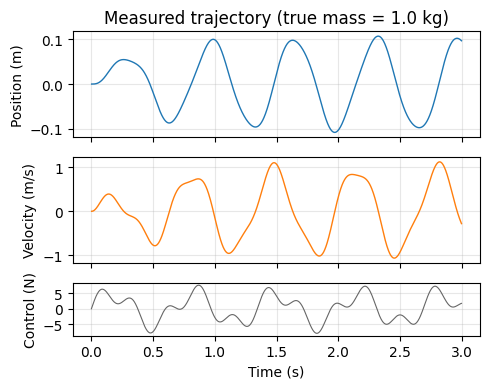

In [ ]:
#@title { vertical-output: true}

# Render the rollout.
frames = sysid.render_rollout(
    model, data, state[None], framerate=30, height=400, width=560
)
media.show_video(frames, fps=30)

control_ts = sysid.TimeSeries(t, ctrl)
sensor_ts = sysid.TimeSeries.from_names(times, sensor, model)

fig, axes = plt.subplots(3, 1, figsize=(5, 4), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

axes[0].plot(times, sensor[:, 0], color="C0", linewidth=1.0)
axes[0].set_ylabel("Position (m)")
axes[0].set_title("Measured trajectory (true mass = 1.0 kg)")

axes[1].plot(times, sensor[:, 1], color="C1", linewidth=1.0)
axes[1].set_ylabel("Velocity (m/s)")

axes[2].plot(t, ctrl[:, 0], color="0.4", linewidth=0.8)
axes[2].set_ylabel("Control (N)")
axes[2].set_xlabel("Time (s)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### システム同定問題の構築

#### 未知のパラメータの定義

`Parameter`は、スカラー（またはベクトル）値を以下の要素でラップします。
- ボックス制約付き最適化のための**バウンド**
- [`MjSpec`](https://mujoco.readthedocs.io/en/stable/python.html#model-editing)に現在の値をスタンプする**モディファイア**コールバック

`nominal`値は固定された参照点です（ここでは後で比較するために真の値に設定しますが、実際には最良の事前推測値となります）。変更可能な`value`は、オプティマイザが実際に更新するものです。

オプティマイザを**質量 = 2.0 kg**、つまり真の値の2倍で開始します。

---

### Building the system identification problem

#### Defining unknown parameters

A `Parameter` wraps a scalar (or vector) value with:
- **bounds** for box-constrained optimization
- a **modifier** callback to stamp its current value onto an [`MjSpec`](https://mujoco.readthedocs.io/en/stable/python.html#model-editing)

The `nominal` value is a fixed reference point (here, we set it to the true value for later comparison, but in practice it would be your best prior guess). The mutable `value` is what the optimizer actually updates.

We start the optimizer with **mass = 2.0 kg**, i.e., twice the true value.


In [ ]:
def set_mass(spec, param):
    """Modifier: stamp the current mass value onto the MjSpec."""
    spec.body("ball").mass = param.value[0]

params = sysid.ParameterDict()
params.add(sysid.Parameter(
    "mass",
    nominal=1.0,
    min_value=0.3,
    max_value=3.0,
    modifier=set_mass,
))

params["mass"].value[:] = 2.0
print(f"Starting mass: {params['mass'].value[0]:.2f} kg  (true: 1.0 kg)")

Starting mass: 2.00 kg  (true: 1.0 kg)


#### データのパッケージ化

`ModelSequences`は、`MjSpec`と1つ以上の測定された軌道
（初期状態、制御、センサー読み取り）をバンドルします。

---

#### Packaging the data

`ModelSequences` bundles an `MjSpec` with one or more measured trajectories
(initial state, controls, sensor readings).


In [ ]:
ms = sysid.ModelSequences(
    "spring_mass", spec, "measured", initial_state, control_ts, sensor_ts,
)

#### 最適化

`build_residual_fn`は、与えられたパラメータベクトルに対して、
パラメータを仕様に適用し、シミュレーションを実行し、
予測されたセンサーデータと測定されたセンサーデータの差を返す呼び出し可能オブジェクトを作成します。
この差は、オプティマイザがゼロに近づける**残差**です。


In [ ]:
residual_fn = sysid.build_residual_fn(models_sequences=[ms])

opt_params, opt_result = sysid.optimize(
    initial_params=params,
    residual_fn=residual_fn,
    optimizer="mujoco",
    verbose=True,
)

print(f"\nRecovered mass: {opt_params['mass'].value[0]:.4f} kg  (true: 1.0 kg)")

INFO:absl:
+----------------------+-----------+-----------+--------------+---------+---------+-------------+-----------+-----------+-----------+
| Parameter            | Initial   | Nominal   | Identified   | Lower   | Upper   | Abs Err     | Abs Del   | Rel Err   | Rel Del   |
+======================+===========+===========+==============+=========+=========+=============+===========+===========+===========+
| mass                 |  2.0000   |  1.0000   |  1.0000      |  0.3000 |  3.0000 |  2.9310e-14 |  1.0000   | 0.0%      | 50.0%     |
+----------------------+-----------+-----------+--------------+---------+---------+-------------+-----------+-----------+-----------+
RMSE: 2.931e-14
RMS Delta: 1


iter: 0    y: 1.824      log10mu: -inf  ratio: 4.1      dx: 0.51     reduction: 0.88   
iter: 1    y: 0.9485     log10mu: -inf  ratio: 1.7      dx: 0.41     reduction: 0.91   
iter: 2    y: 0.03887    log10mu: -inf  ratio: 1        dx: 0.084    reduction: 0.039  
iter: 3    y: 1.188e-05  log10mu: -inf  ratio: 1        dx: 0.0015   reduction: 1.2e-05
iter: 4    y: 8.588e-13  log10mu: -inf  ratio: 1        dx: 4e-07    reduction: 8.6e-13
Terminated after 5 iterations: norm(gradient) < tol. y: 4.55e-27, Residual evals: 13
total time 89.7ms of which residual 98.6%

Recovered mass: 1.0000 kg  (true: 1.0 kg)


#### レポート

最適化された予測がノミナル（グラウンドトゥルース）に適合し、
初期のセンサー予測が適合しないことを確認するためにレポートを検査します。

レポートには、測定値の比較、パラメータテーブル、信頼区間、
およびその他のデバッグ情報も含まれています。

---

#### Report

We inspect the report to confirm that the optimized prediction fits the nominal (ground truth), while the initial sensor prediction does not.

The report also includes a comparison of measured values, a parameter table, confidence intervals,
and other debugging information.


In [ ]:
report = sysid.default_report(
    models_sequences=[ms],
    initial_params=params,
    opt_params=opt_params,
    residual_fn=residual_fn,
    opt_result=opt_result,
    title="Mass Spring Damper Identification",
    generate_videos=False,
)
display_report(report)

<a name="api"></a>
# 2. API

ウォームアップでは、`Parameter`、`TimeSeries`、`ModelSequences`をざっと紹介しました。ここでは、それぞれをより詳しく見ていきます。

---

<a name="api"></a>
# 2. API

In the warm-up, we had a quick look at `Parameter`, `TimeSeries`, and `ModelSequences`. Here, we take a closer look at each.


## ParameterDict

ウォームアップでは、名前、境界、およびモディファイアコールバックを持つ単一の`Parameter`を作成しました。`ParameterDict`は、複数のパラメータをオプティマイザ用にグループ化します。

パラメータは**フリーズ**することができます。これにより、最適化ベクトルから除外されますが、フリーズされた値でモディファイアは引き続き適用されます。

---

## ParameterDict

In the warm-up, we created a single `Parameter` with a name, bounds, and a modifier callback. A `ParameterDict` groups multiple parameters for the optimizer.

Parameters can be **frozen**. This excludes them from the optimization vector, but the modifier will still apply with the frozen value.


In [ ]:
# Three parameters for the spring-mass model. Damping is frozen.
params = sysid.ParameterDict()
params.add(sysid.Parameter(
    "mass", nominal=1.0, min_value=0.3, max_value=3.0,
    modifier=lambda s, p: setattr(s.body("ball"), "mass", p.value[0]),
))
params.add(sysid.Parameter(
    "stiffness", nominal=100.0, min_value=30.0, max_value=300.0,
    modifier=lambda s, p: setattr(s.joint("slide"), "stiffness", p.value[0]),
))
params.add(sysid.Parameter(
    "damping", nominal=5.0, min_value=0.0, max_value=20.0, frozen=True,
    modifier=lambda s, p: setattr(s.joint("slide"), "damping", p.value[0]),
))

print("Parameter vector (excludes frozen):", params.as_vector())
print("Bounds:", params.get_bounds())
print("Frozen 'damping' still in dict:    ", params["damping"].value)

Parameter vector (excludes frozen): [  1. 100.]
Bounds: (array([ 0.3, 30. ]), array([  3., 300.]))
Frozen 'damping' still in dict:     [5.]


## TimeSeries

`TimeSeries`は、タイムスタンプ付き信号の不変コンテナです。ウォームアップで使用した`from_names`ファクトリは、センサー名から列インデックスへの**信号マッピング**（辞書）を自動的に作成します。このマッピングにより、ライブラリは予測された信号と測定された信号を名前で照合できます。

`TimeSeries`は、異なるタイムステップへのリサンプリングもサポートしており、測定データとシミュレーションが異なるレートで実行される場合に役立ちます。

---

## TimeSeries

A `TimeSeries` is an immutable container for timestamped signals. The `from_names` factory, which we used in the warm-up, automatically creates a **signal mapping** (a dictionary) from sensor names to column indices. This mapping enables the library to match predicted and measured signals by name.

`TimeSeries` also supports resampling to different timesteps, which can be useful when measured and simulated data run at different rates.


In [ ]:
# sensor_ts was created in the warm-up with from_names
print("Signal mapping:", sensor_ts.signal_mapping)

# Resample to a coarser timestep (returns a new TimeSeries)
ts_coarse = sensor_ts.resample(target_dt=0.01)
print(f"Original: {len(sensor_ts.times)} pts  ->  Resampled: {len(ts_coarse.times)} pts")

Signal mapping: {'position': (<SignalType.MjSensor: 0>, array([0])), 'velocity': (<SignalType.MjSensor: 0>, array([1]))}
Original: 1499 pts  ->  Resampled: 301 pts


## ModelSequences

`ModelSequences`は、`MjSpec`と1つ以上の測定された軌道（初期状態、制御、センサー読み取り）をバンドルします。これは`build_residual_fn`への入力となります。

同じスペックに対して**複数の軌道**を渡すことができます。これは、次のセクションで説明するように、パラメータの識別可能性を向上させるための主要なメカニズムです。

---

## ModelSequences

A `ModelSequences` bundles an `MjSpec` with one or more measured trajectories (initial state, controls, sensor readings). This is the input to `build_residual_fn`.

You can pass **multiple trajectories** for the same spec. This is a key mechanism for improving parameter identifiability, as we discuss in the next section.


In [ ]:
# Single trajectory (as in the warm-up)
ms_single = sysid.ModelSequences(
    "spring_mass", spec, "traj_0", initial_state, control_ts, sensor_ts,
)
print(f"Single trajectory: {ms_single.sequence_name}")

# Multiple trajectories for the same spec -- just pass lists
ms_multi = sysid.ModelSequences(
    "spring_mass", spec,
    ["traj_0", "traj_1"],           # names
    [initial_state, initial_state], # initial states
    [control_ts, control_ts],       # controls
    [sensor_ts, sensor_ts],         # sensor data
)
print(f"Multiple trajectories: {ms_multi.sequence_name}")

Single trajectory: ['traj_0']
Multiple trajectories: ['traj_0', 'traj_1']


<a name="robot-arm"></a>
# 4. ロボットアーム: 関節アーマチュアの特定

ここでは、現実的な問題に取り組みます。5自由度のロボットアームはモーターアクチュエータによって関節トルクを印加され、アーマチュアは未知です。アーマチュアはギアトレインを介した反射ローター慣性を表します。これはシムとリアルのギャップの一般的な原因です。アーマチュアが間違っていると、同じ印加トルクに対してシミュレートされたアームの加速が速すぎたり遅すぎたりします。詳細については、[こちら](https://mujoco.readthedocs.io/en/stable/XMLreference.html#body-joint-armature)で読むことができます。

---

<a name="robot-arm"></a>
# 4. Robot Arm: Identifying Joint Armatures

Here, we tackle a realistic problem: a 5-DOF robot arm is commanded joint torques by motor actuators, and the armatures are unknown. Armatures represent reflected rotor inertia through a gear train. This is a common source of sim-to-real gap: if armatures are wrong, then a simulated arm accelerates too quickly or too slowly for the same applied torque. You can read more about it [here](https://mujoco.readthedocs.io/en/stable/XMLreference.html#body-joint-armature).


### アームモデル

モーターアクチュエータ（トルク制御）によって駆動される5つのヒンジジョイント。関節ダンピングは受動的な散逸を提供します。真のアーマチュア値は、基部から先端に向かって減少し、遠位関節のモーターが小さいことを反映しています。すべての関節に位置センサーがあります。

---

### Arm model

Five hinge joints driven by motor actuators (torque-controlled). Joint damping provides passive dissipation. True armature values decrease from base to tip, reflecting smaller motors in distal joints. All joints have position sensors.


In [ ]:
#@title ARM_XML { vertical-output: true}
ARM_XML = """\
<mujoco model="arm">
  <compiler angle="radian" autolimits="true"/>
  <option integrator="implicitfast" timestep="0.002">
    <flag contact="disable"/>
  </option>
  <worldbody>
    <body name="link1" pos="0 0 0.1">
      <inertial pos="0 0 0.05" mass="1.0" diaginertia="0.01 0.01 0.005"/>
      <joint name="joint1" type="hinge" axis="0 0 1" range="-3.14 3.14"
             armature="0.5" damping="1.0"/>
      <geom type="capsule" fromto="0 0 0 0 0 0.1" size="0.04"/>
      <body name="link2" pos="0 0 0.1">
        <inertial pos="0 0 0.05" mass="0.8" diaginertia="0.008 0.008 0.004"/>
        <joint name="joint2" type="hinge" axis="0 1 0" range="-3.14 3.14"
               armature="0.4" damping="0.8"/>
        <geom type="capsule" fromto="0 0 0 0 0 0.1" size="0.035"/>
        <body name="link3" pos="0 0 0.1">
          <inertial pos="0 0 0.05" mass="0.6" diaginertia="0.006 0.006 0.003"/>
          <joint name="joint3" type="hinge" axis="0 1 0" range="-3.14 3.14"
                 armature="0.3" damping="0.6"/>
          <geom type="capsule" fromto="0 0 0 0 0 0.1" size="0.03"/>
          <body name="link4" pos="0 0 0.1">
            <inertial pos="0 0 0.04" mass="0.4" diaginertia="0.004 0.004 0.002"/>
            <joint name="joint4" type="hinge" axis="0 0 1" range="-3.14 3.14"
                   armature="0.2" damping="0.4"/>
            <geom type="capsule" fromto="0 0 0 0 0 0.08" size="0.025"/>
            <body name="link5" pos="0 0 0.08">
              <inertial pos="0 0 0.03" mass="0.2" diaginertia="0.002 0.002 0.001"/>
              <joint name="joint5" type="hinge" axis="0 1 0" range="-3.14 3.14"
                     armature="0.1" damping="0.2"/>
              <geom type="capsule" fromto="0 0 0 0 0 0.06" size="0.02"/>
            </body>
          </body>
        </body>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="act1" joint="joint1"/>
    <motor name="act2" joint="joint2"/>
    <motor name="act3" joint="joint3"/>
    <motor name="act4" joint="joint4"/>
    <motor name="act5" joint="joint5"/>
  </actuator>
  <sensor>
    <jointpos name="joint1_pos" joint="joint1"/>
    <jointpos name="joint2_pos" joint="joint2"/>
    <jointpos name="joint3_pos" joint="joint3"/>
    <jointpos name="joint4_pos" joint="joint4"/>
    <jointpos name="joint5_pos" joint="joint5"/>
  </sensor>
</mujoco>
"""

JOINT_NAMES = ["joint1", "joint2", "joint3", "joint4", "joint5"]
TRUE_ARMATURE = {"joint1": 0.5, "joint2": 0.4, "joint3": 0.3,
                 "joint4": 0.2, "joint5": 0.1}

### 測定データの生成

真のモデルをシミュレーションし、センサーノイズを追加して実際のエンコーダの読み取り値を模倣します。多周波数トルク励起により、各関節が十分に励起されます。モーターアクチュエータを使用する場合、制御信号はトルクであるため、アーマチュアの影響を隠すフィードバックループはありません。

---

### Generating measured data

We simulate the true model and add sensor noise to mimic a real encoder reading. The multi-frequency torque excitation ensures each joint is well-excited. When using motor actuators, the control signal is torque, so there are no feedback loops to mask the armature effect.

In [ ]:
spec = mujoco.MjSpec.from_string(ARM_XML)
model = spec.compile()
data = mujoco.MjData(model)

duration = 2.0
n_steps = int(duration / model.opt.timestep)
t = np.arange(n_steps) * model.opt.timestep

# Sinusoidal torques with different frequency and amplitude per joint
ctrl = np.column_stack([
    5.0 * np.sin(2 * np.pi * 0.5 * t),
    4.0 * np.sin(2 * np.pi * 0.7 * t + 0.5),
    3.0 * np.sin(2 * np.pi * 0.4 * t + 1.0),
    2.0 * np.sin(2 * np.pi * 0.9 * t + 1.5),
    1.0 * np.sin(2 * np.pi * 0.6 * t + 2.0),
])

initial_state = sysid.create_initial_state(model, data.qpos, data.qvel, data.act)
state, sensor = rollout.rollout(model, data, initial_state, ctrl[:-1])
state = np.squeeze(state, axis=0)
sensor = np.squeeze(sensor, axis=0)
times = state[:, 0]

# Add realistic sensor noise
rng = np.random.default_rng(seed=0)
noise_std = np.zeros(sensor.shape[1])
noise_std[:] = 0.6   # position noise (rad)
sensor_noisy = sensor + rng.normal(scale=noise_std, size=sensor.shape)

control_ts = sysid.TimeSeries(t, ctrl)
sensor_ts = sysid.TimeSeries.from_names(times, sensor_noisy, model)

print(f"Sensor channels: {sensor.shape[1]}  "
      f"({model.nsensor} sensors: 5 pos + 5 vel)")
print(f"Timesteps: {len(times)} ({duration}s at dt={model.opt.timestep})")
print(f"Noise std: {noise_std[:5][0]:.0e} rad (pos)")

Sensor channels: 5  (5 sensors: 5 pos + 5 vel)
Timesteps: 999 (2.0s at dt=0.002)
Noise std: 6e-01 rad (pos)


### アーマチュアパラメータの定義

各関節に1つのスカラーパラメータを設定します。モディファイアコールバックは、スペック上の関節の`armature`属性を設定します。すべての関節に対して**基部関節の最大50倍小さい**0.01という誤った初期推測値から開始します。

---

### Defining armature parameters

We define one scalar parameter per joint. The modifier callback sets the joint's `armature` attribute on the spec. We start from a wrong initial guess of **0.01**, up to 50x smaller than the base joint.

In [ ]:
INIT_ARMATURE = 0.01

def make_armature_modifier(joint_name):
    """Create a modifier that sets armature on a specific joint."""
    def modifier(spec, param):
        spec.joint(joint_name).armature = param.value[0]
    return modifier

params = sysid.ParameterDict()
for name in JOINT_NAMES:
    true_val = TRUE_ARMATURE[name]
    params.add(sysid.Parameter(
        f"{name}_armature",
        nominal=true_val,
        min_value=0.01,
        max_value=0.6,
        modifier=make_armature_modifier(name),
    ))
    # Start from wrong initial guess
    params[f"{name}_armature"].value[:] = INIT_ARMATURE

print("Initial parameter vector:", params.as_vector())
print("True values:             ",
      np.array([TRUE_ARMATURE[n] for n in JOINT_NAMES]))

Initial parameter vector: [0.01 0.01 0.01 0.01 0.01]
True values:              [0.5 0.4 0.3 0.2 0.1]


### 最適化

---

### Optimize


In [ ]:
#@title { vertical-output: true}
ms = sysid.ModelSequences(
    "arm", spec, "sinusoidal", initial_state, control_ts, sensor_ts,
)

residual_fn = sysid.build_residual_fn(models_sequences=[ms])

opt_params, opt_result = sysid.optimize(
    initial_params=params,
    residual_fn=residual_fn,
    optimizer="mujoco",
)

iter: 0    y: 4.064      log10mu: -inf  ratio: 1.6      dx: 0.26     reduction: 1.6    
iter: 1    y: 2.439      log10mu: -inf  ratio: 1.1      dx: 0.28     reduction: 0.62   
iter: 2    y: 1.817      log10mu: -inf  ratio: 1        dx: 0.2      reduction: 0.11   
iter: 3    y: 1.703      log10mu: -inf  ratio: 0.99     dx: 0.066    reduction: 0.0069 
iter: 4    y: 1.696      log10mu: -inf  ratio: 1        dx: 0.0047   reduction: 6.1e-05
iter: 5    y: 1.696      log10mu: -inf  ratio: 1        dx: 0.00017  reduction: 7.7e-08
iter: 6    y: 1.696      log10mu: -inf  ratio: 1        dx: 3.2e-06  reduction: 2.4e-11
iter: 7    y: 1.696      log10mu: -inf  ratio: 1        dx: 5.7e-08  reduction: 7.3e-15


INFO:absl:
+----------------------+-----------+-----------+--------------+---------+---------+-------------+-----------+-----------+-----------+
| Parameter            | Initial   | Nominal   | Identified   | Lower   | Upper   | Abs Err     | Abs Del   | Rel Err   | Rel Del   |
+======================+===========+===========+==============+=========+=========+=============+===========+===========+===========+
| joint1_armature      |  0.0100   |  0.5000   |  0.5165      |  0.0100 |  0.6000 |  0.0165     |  0.5065   | 3.3%      |           |
| joint2_armature      |  0.0100   |  0.4000   |  0.4254      |  0.0100 |  0.6000 |  0.0254     |  0.4154   | 6.3%      |           |
| joint3_armature      |  0.0100   |  0.3000   |  0.2972      |  0.0100 |  0.6000 |  2.7558e-03 |  0.2872   | 0.9%      |           |
| joint4_armature      |  0.0100   |  0.2000   |  0.1872      |  0.0100 |  0.6000 |  0.0128     |  0.1772   | 6.4%      | 1772.4%   |
| joint5_armature      |  0.0100   |  0.1000   |  0

iter: 8    y: 1.696      log10mu:  4.2  ratio: 1.7e+04  dx: 9e-13    reduction: 2.2e-16
Terminated after 8 iterations: norm(dx) < tol. y: 1.696, Residual evals: 163
total time 1.2s of which residual 99.2%


#### レポート

**信頼区間。**測定データにはセンサーノイズが含まれるため、最適な残差には分散があり、これを使用して95%のパラメータ信頼区間を推定できます。これらはレポートの「パラメータ分布」セクションに表示されます。

---

#### Report

**Confidence Intervals.** Because our measured data includes sensor noise, the optimal residual will have some variance, which we can use to estimate 95% parameter confidence intervals. These are shown in the "Parameter Distribution" section of the report.

In [ ]:
report = sysid.default_report(
    models_sequences=[ms],
    initial_params=params,
    opt_params=opt_params,
    residual_fn=residual_fn,
    opt_result=opt_result,
    title="Robot Arm Armature Identification",
    generate_videos=False,
)
display_report(report)

### レンダリングされたオーバーレイ: 初期値 vs. 最適化値 vs. 真値

`render_rollout`は、モデルのリストと状態軌道のバッチを受け取り、それらを単一のシーンにレンダリングします。これにより、異なるパラメータ値がモーションにどのように影響するかを視覚的に比較できます。2つの動画を並べてレンダリングします。
- **Before:** 初期推測値（赤） vs. 真値（緑）
- **After:** 最適化値（青） vs. 真値（緑）

---

### Rendered overlay: initial vs. optimized vs. truth

`render_rollout` takes a batch of models and state trajectories and renders them into a single scene. This allows for visual comparison of how different parameter values affect the motion. We'll render two videos side-by-side:
- **Before:** initial guess (red) vs. ground truth (green)
- **After:** optimized (blue) vs. ground truth (green)

In [ ]:
#@title { vertical-output: true}
def set_body_rgba(body, rgba):
    """Recursively set rgba on all geoms in a body tree."""
    for geom in body.geoms:
        geom.rgba = rgba
    for child in body.bodies:
        set_body_rgba(child, rgba)

def make_colored_model(base_spec, rgba, armature_values):
    """Copy spec, set geom colors and armature, compile."""
    s = base_spec.copy()
    for name, val in armature_values.items():
        s.joint(name).armature = val
    set_body_rgba(s.worldbody, rgba)
    return s.compile()

true_armature = {n: TRUE_ARMATURE[n] for n in JOINT_NAMES}
init_armature = {n: INIT_ARMATURE for n in JOINT_NAMES}
opt_armature = {n: opt_params[f"{n}_armature"].value[0] for n in JOINT_NAMES}

green = [0.2, 0.8, 0.2, 0.7]
red = [1.0, 0.2, 0.2, 0.7]
blue = [0.2, 0.4, 1.0, 0.7]

truth_model = make_colored_model(spec, green, true_armature)
init_model = make_colored_model(spec, red, init_armature)
opt_model = make_colored_model(spec, blue, opt_armature)

fps = 30

# Before: initial (red) vs ground truth (green)
models_before = [init_model, truth_model]
datas_before = [mujoco.MjData(m) for m in models_before]
state_before, _ = rollout.rollout(
    models_before, datas_before, initial_state, ctrl[:-1]
)
frames_before = sysid.render_rollout(
    models_before, datas_before[0], state_before,
    framerate=fps, height=400, width=560,
)

# After: optimized (blue) vs ground truth (green)
models_after = [opt_model, truth_model]
datas_after = [mujoco.MjData(m) for m in models_after]
state_after, _ = rollout.rollout(
    models_after, datas_after, initial_state, ctrl[:-1]
)
frames_after = sysid.render_rollout(
    models_after, datas_after[0], state_after,
    framerate=fps, height=400, width=560,
)

# Side by side
media.show_videos(
    [frames_before, frames_after],
    fps=fps,
    titles=["Before: initial (red) vs truth (green)",
            "After: optimized (blue) vs truth (green)"],
)

Before: initial (red) vs truth (green) This browser does not support the video tag.,After: optimized (blue) vs truth (green) This browser does not support the video tag.


<a name="ambiguity"></a>
# 4. パラメータの識別可能性

単一の実験では、すべてのパラメータを一意に決定できない場合があります。これは[構造的識別可能性](https://en.wikipedia.org/wiki/Structural_identifiability)の概念に関連しています。

モーターによって駆動される台車を考えてみましょう。

$$m\,\ddot x = b\,u(t)$$

ここで、$m$ は台車の質量、$b$ はトルク定数（[`gear`](https://mujoco.readthedocs.io/en/stable/XMLreference.html#actuator-general-gear)）です。応答は$b/m$ の**比率にのみ依存**します。$b$ と $m$ の両方を2倍にしても、同じ軌道が生成されます。単一の記録では、個々の値は本質的に識別できません。

ここでは、曖昧さを視覚化し、既知の質量摂動で記録された**2番目の軌道**に対して最適化することで、これを解決します。

---

<a name="ambiguity"></a>
# 4. Parameter Identifiability

A single experiment may not uniquely determine all parameters. This relates to the concept of [structural identifiability](https://en.wikipedia.org/wiki/Structural_identifiability).

Consider a cart actuated by a motor:

$$m\,\ddot x = b\,u(t)$$

where $m$ is the cart's mass and $b$ is the torque constant ([`gear`](https://mujoco.readthedocs.io/en/stable/XMLreference.html#actuator-general-gear)). The response **only depends on the ratio** $b/m$. Doubling both $b$ and $m$ will produce the exact same trajectory. In a single recording, the individual values are fundamentally unidentifiable.

Here, we'll visualize the ambiguity and resolve it by optimizing against a **second trajectory** recorded with a known mass perturbation.

In [ ]:
#@title CART_XML { vertical-output: true}
CART_XML = """\
<mujoco model="cart">
  <option timestep="0.002">
    <flag contact="disable"/>
  </option>
  <worldbody>
    <body name="cart" pos="0 0 0.1">
      <inertial pos="0 0 0" mass="2.0" diaginertia="0.001 0.001 0.001"/>
      <joint name="slide" type="slide" axis="1 0 0"/>
      <geom type="sphere" size="0.05"/>
    </body>
  </worldbody>
  <actuator>
    <motor name="motor" joint="slide" gear="3.0"/>
  </actuator>
  <sensor>
    <jointpos name="position" joint="slide"/>
    <jointvel name="velocity" joint="slide"/>
  </sensor>
</mujoco>
"""

TRUE_MASS = 2.0
TRUE_GEAR = 3.0
PAYLOAD_MASS = 1.0

# Base cart
spec_base = mujoco.MjSpec.from_string(CART_XML)

# Payload variant: add a rigid mass to the cart body
spec_pay = mujoco.MjSpec.from_string(CART_XML)
payload = spec_pay.body("cart").add_body()
payload.name = "payload"
payload.mass = PAYLOAD_MASS
payload.inertia = [0.001, 0.001, 0.001]

### 両方の構成のデータを生成する

---

### Generate data for both configurations


In [ ]:
#@title generate_data() { vertical-output: true}
def generate_data(spec, duration=0.6):
    """Rollout a spec and return (control_ts, sensor_ts, initial_state)."""
    model = spec.compile()
    data = mujoco.MjData(model)

    n_steps = int(duration / model.opt.timestep)
    t = np.arange(n_steps) * model.opt.timestep

    ctrl = (3.0 * np.sin(2 * np.pi * 2.0 * t)
            + 2.0 * np.sin(2 * np.pi * 5.0 * t)).reshape(-1, 1)

    initial_state = sysid.create_initial_state(
        model, data.qpos, data.qvel, data.act
    )
    state, sensor = rollout.rollout(model, data, initial_state, ctrl[:-1])
    state = np.squeeze(state, axis=0)
    sensor = np.squeeze(sensor, axis=0)
    times = state[:, 0]

    control_ts = sysid.TimeSeries(t, ctrl)
    sensor_ts = sysid.TimeSeries.from_names(times, sensor, model)
    return control_ts, sensor_ts, initial_state


ctrl_base, sens_base, state0_base = generate_data(spec_base)
ctrl_pay, sens_pay, state0_pay = generate_data(spec_pay)

### パラメータを定義: 質量とギア

---

### Define parameters: mass and gear


In [ ]:
def set_cart_mass(spec, param):
    spec.body("cart").mass = param.value[0]

def set_gear_ratio(spec, param):
    spec.actuator("motor").gear[0] = param.value[0]

def make_params(mass_init, gear_init):
    """Create a ParameterDict with given starting values."""
    params = sysid.ParameterDict()
    params.add(sysid.Parameter(
        "mass", nominal=TRUE_MASS, min_value=0.5, max_value=5.0,
        modifier=set_cart_mass,
    ))
    params.add(sysid.Parameter(
        "gear", nominal=TRUE_GEAR, min_value=0.5, max_value=8.0,
        modifier=set_gear_ratio,
    ))
    params["mass"].value[:] = mass_init
    params["gear"].value[:] = gear_init
    return params

### 試行1：単一シーケンス（基本台車のみ）

$b/m = 1.5$ の正しい比率を持ちながら、個々の値が間違っている $m = 3.5,\; b = 5.25$ から開始します。コストは $b/m = 1.5$ に沿って完全にゼロであるため、オプティマイザは追跡すべき勾配を持ちません。

---

### Trial 1: Single sequence (base cart only)

We start from wrong individual values $m=3.5, \; b=5.25$, while still having the correct ratio of $b/m=1.5$. The cost is perfectly zero along $b/m=1.5$, so the optimizer has no gradient to follow.

In [ ]:
params_1seq = make_params(mass_init=3.5, gear_init=5.25)

ms_base = sysid.ModelSequences(
    "cart", spec_base, "base_traj", state0_base, ctrl_base, sens_base,
)

residual_fn_1seq = sysid.build_residual_fn(models_sequences=[ms_base])

opt_1seq, result_1seq = sysid.optimize(
    initial_params=params_1seq,
    residual_fn=residual_fn_1seq,
    optimizer="mujoco",
)

print(f"\n--- Single sequence ---")
print(f"  mass:  {opt_1seq['mass'].value[0]:.4f}  (true: {TRUE_MASS})")
print(f"  gear:  {opt_1seq['gear'].value[0]:.4f}  (true: {TRUE_GEAR})")
print(f"  b/m:   {opt_1seq['gear'].value[0] / opt_1seq['mass'].value[0]:.4f}"
      f"  (true: {TRUE_GEAR / TRUE_MASS:.4f})")

INFO:absl:
+----------------------+-----------+-----------+--------------+---------+---------+-----------+-------------+-----------+-----------+
| Parameter            | Initial   | Nominal   | Identified   | Lower   | Upper   | Abs Err   | Abs Del     | Rel Err   | Rel Del   |
+======================+===========+===========+==============+=========+=========+===========+=============+===========+===========+
| mass                 |  3.5000   |  2.0000   |  3.5000      |  0.5000 |  5.0000 |  1.5000   |  0.0000e+00 | 75.0%     | 0.0%      |
| gear                 |  5.2500   |  3.0000   |  5.2500      |  0.5000 |  8.0000 |  2.2500   |  0.0000e+00 | 75.0%     | 0.0%      |
+----------------------+-----------+-----------+--------------+---------+---------+-----------+-------------+-----------+-----------+
RMSE: 1.912
RMS Delta: 0


Terminated after 0 iterations: norm(gradient) < tol. y: 2.099e-32, Residual evals: 5
total time 18.1ms of which residual 98.0%

--- Single sequence ---
  mass:  3.5000  (true: 2.0)
  gear:  5.2500  (true: 3.0)
  b/m:   1.5000  (true: 1.5000)


オプティマイザは**間違った**個々の値に即座に収束しました！
比率 $b/m$ は正しいですが、オプティマイザには $m$ と $b$ を個別に決定する方法がありません。

---

The optimizer immediately converged to the **wrong** individual values! The ratio $b/m$ is correct, but the optimizer has no way to individually determine $m$ and $b.

### 試行2：2つのシーケンス（基本 + 1 kgのペイロード）

**既知の1.0 kgのペイロード**を持つ2番目の軌道を追加することで、オプティマイザに2つ目の式が与えられます。
- ベース：    加速度 $= b / m$
- ペイロード： 加速度 $= b / (m + 1)$

2つの式、2つの未知数。

---

### Trial 2: Two sequences (base + 1 kg payload)

By adding a second trajectory with a **known 1.0 kg payload**, we give the optimizer a second equation:
- base:    acceleration $= b / m$
- payload: acceleration $= b / (m + 1)$

Two equations, two unknowns.

In [ ]:
params_2seq = make_params(mass_init=3.5, gear_init=5.25)

ms_payload = sysid.ModelSequences(
    "cart_payload", spec_pay, "payload_traj", state0_pay, ctrl_pay, sens_pay,
)

residual_fn_2seq = sysid.build_residual_fn(
    models_sequences=[ms_base, ms_payload],
)

opt_2seq, result_2seq = sysid.optimize(
    initial_params=params_2seq,
    residual_fn=residual_fn_2seq,
    optimizer="mujoco",
)

print(f"\n--- Two sequences (base + payload) ---")
print(f"  mass:  {opt_2seq['mass'].value[0]:.4f}  (true: {TRUE_MASS})")
print(f"  gear:  {opt_2seq['gear'].value[0]:.4f}  (true: {TRUE_GEAR})")
print(f"  b/m:   {opt_2seq['gear'].value[0] / opt_2seq['mass'].value[0]:.4f}"
      f"  (true: {TRUE_GEAR / TRUE_MASS:.4f})")

INFO:absl:
+----------------------+-----------+-----------+--------------+---------+---------+-------------+-----------+-----------+-----------+
| Parameter            | Initial   | Nominal   | Identified   | Lower   | Upper   | Abs Err     | Abs Del   | Rel Err   | Rel Del   |
+======================+===========+===========+==============+=========+=========+=============+===========+===========+===========+
| mass                 |  3.5000   |  2.0000   |  2.0000      |  0.5000 |  5.0000 |  8.1491e-09 |  1.5000   | 0.0%      | 42.9%     |
| gear                 |  5.2500   |  3.0000   |  3.0000      |  0.5000 |  8.0000 |  1.0593e-08 |  2.2500   | 0.0%      | 42.9%     |
+----------------------+-----------+-----------+--------------+---------+---------+-------------+-----------+-----------+-----------+
RMSE: 9.45e-09
RMS Delta: 1.912


iter: 0    y: 0.05556    log10mu: -4.9  ratio: 0.023    dx: 4        reduction: 0.0013 
iter: 1    y: 0.05427    log10mu: -4.8  ratio: 0.96     dx: 1        reduction: 0.052  
iter: 2    y: 0.002134   log10mu: -4.9  ratio: 1        dx: 0.31     reduction: 0.0021 
iter: 3    y: 7.094e-06  log10mu: -5.1  ratio: 1        dx: 0.02     reduction: 7.1e-06
iter: 4    y: 1.098e-10  log10mu: -5.5  ratio: 1        dx: 8.2e-05  reduction: 1.1e-10
Terminated after 5 iterations: norm(gradient) < tol. y: 1.918e-18, Residual evals: 32
total time 229.4ms of which residual 99.1%

--- Two sequences (base + payload) ---
  mass:  2.0000  (true: 2.0)
  gear:  3.0000  (true: 3.0)
  b/m:   1.5000  (true: 1.5000)


### コストランドスケープを可視化

$(m, b)$ 値のグリッド上でコストを評価し、縮退を調べてみましょう。

---

### Visualize the cost landscape

Let's evaluate the cost on a grid of $(m, b)$ values and inspect the degeneracy.

In [ ]:
#@title compute_cost_surface() { vertical-output: true}
mass_grid = np.linspace(0.6, 4.5, 35)
gear_grid = np.linspace(0.6, 7.5, 35)

def compute_cost_surface(residual_fn, params_template):
    """Evaluate cost on a (mass, gear) grid."""
    cost = np.zeros((len(mass_grid), len(gear_grid)))
    p = params_template.copy()
    for i, m in enumerate(mass_grid):
        for j, g in enumerate(gear_grid):
            x = np.array([m, g])
            res, _, _ = residual_fn(x, p)
            cost[i, j] = sum(np.sum(r**2) for r in res)
    return cost

cost_1seq = compute_cost_surface(residual_fn_1seq, params_1seq)
cost_2seq = compute_cost_surface(residual_fn_2seq, params_2seq)

### 並列コストランドスケープ

---

### Side-by-side cost landscapes


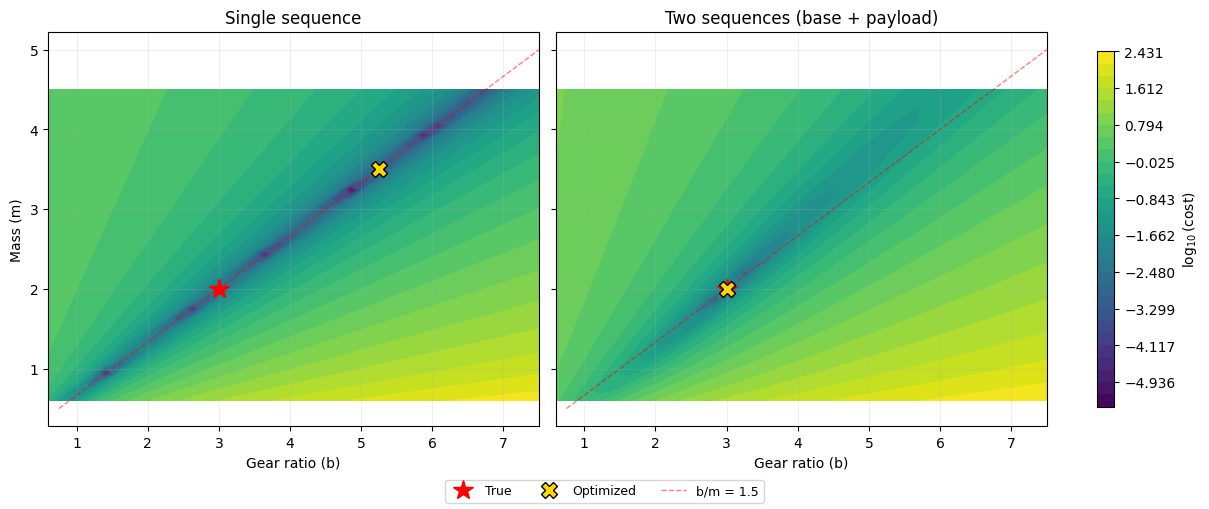

In [ ]:
#@title { vertical-output: true}
G, M = np.meshgrid(gear_grid, mass_grid)

# Compute log cost with shared color range across both panels
log_cost_1 = np.log10(cost_1seq + 1e-12)
log_cost_2 = np.log10(cost_2seq + 1e-12)
vmin = min(log_cost_1.min(), log_cost_2.min())
vmax = max(log_cost_1.max(), log_cost_2.max())
levels = np.linspace(vmin, vmax, 30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                         layout="constrained")

for ax, log_cost, title, opt_p in [
    (axes[0], log_cost_1, "Single sequence", opt_1seq),
    (axes[1], log_cost_2, "Two sequences (base + payload)", opt_2seq),
]:
    cf = ax.contourf(G, M, log_cost, levels=levels, cmap="viridis")

    ax.plot(TRUE_GEAR, TRUE_MASS, "r*", markersize=15, label="True", zorder=5)
    ax.plot(opt_p["gear"].value[0], opt_p["mass"].value[0],
            marker="X", color="gold", markeredgecolor="k", markeredgewidth=1,
            markersize=12, linestyle="none", label="Optimized", zorder=5)

    m_line = np.linspace(0.5, 5.0, 200)
    ax.plot(1.5 * m_line, m_line, "r--", alpha=0.5, lw=1, label="b/m = 1.5")

    ax.set_xlabel("Gear ratio (b)")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Mass (m)")

# Shared colorbar
fig.colorbar(cf, ax=axes, label=r"$\log_{10}$(cost)", shrink=0.9)

# Single legend below both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, fontsize=9)

plt.show()

**左:** 単一のシーケンスでは、コストは $b/m = 1.5$ のライン全体にわたって**完全にゼロ**です。勾配を追うべきものがないため、オプティマイザは開始点にとどまります。質量とギアは根本的に識別できません。

**右:** ペイロード軌道を追加すると、谷は真のパラメータ値 $(m=2, b=3)$ にある局所的な最小値に収束します。

**教訓:** 識別不可能なパラメータを持つモデルは簡単に作成できます。この場合、多様な励起や構造摂動（例：質量追加）を追加することで解決できます。

---

**Left:** For the single sequence, the cost is **perfectly zero** along the entire $b/m = 1.5$ line. Since there's no gradient for the optimizer to follow, it stays at the starting point. The mass and gear are fundamentally unidentifiable.

**Right:** Adding the payload trajectory causes the valley to converge to a local minimum at the true parameter values ($m=2, b=3$).

**The lesson:** It's easy to create models with unidentifiable parameters. This can be resolved by adding diverse excitation or structural perturbations (e.g., adding mass) in the case above.


# 結論

MuJoCoを使ったシステム同定の紹介をお楽しみいただけたでしょうか。
このライブラリには、ここでは触れていない追加機能があります。

- **[物理的に妥当な慣性パラメータ化](https://ieeexplore.ieee.org/document/9690029)**
  結果が物理的に有効であることを保証しながら、質量、重心、回転慣性を特定するため
- **センサーごとの重み付け** コストにおいて特定のセンサーを強調するため
- **ロバストな損失関数** (Huber, Cauchyなど)
  測定データにおける外れ値を処理するため（非二次ノルムの詳細については、
  [最小二乗](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/least_squares.ipynb)
  ノートブックを参照）
- **複数のオプティマイザバックエンド** (MuJoCoネイティブ、scipy、scipyと並列有限差分)

この分野の包括的な調査については、
[Robot Model Identification and Learning: A Modern Perspective](https://www.annualreviews.org/content/journals/10.1146/annurev-control-061523-102310)
（Annual Review of Control, Robotics, and Autonomous Systems, 2024）を参照してください。

---

# Conclusion

We hope you enjoyed this introduction to system identification with MuJoCo. There are additional capabilities in the library that we haven't covered here:

- **[Physically plausible inertia parameterizations](https://ieeexplore.ieee.org/document/9690029)**
  for identifying mass, center of mass, and rotational inertia while ensuring the results
  are physically valid
- **Per-sensor weighting** for emphasizing specific sensors in the cost
- **Robust loss functions** (e.g., Huber, Cauchy) for handling outliers in measured data
  (see the [Least Squares](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/least_squares.ipynb)
  notebook for more details on non-quadratic norms)
- **Multiple optimizer backends** (MuJoCo native, scipy, scipy with parallel finite-differencing)

For a comprehensive survey of this area, see
[Robot Model Identification and Learning: A Modern Perspective](https://www.annualreviews.org/content/journals/10.1146/annurev-control-061523-102310)
(Annual Review of Control, Robotics, and Autonomous Systems, 2024).


#ここから自作

背景:

現在ラズベリーパイ５・CANシールド・CubemarsAK45-36（モーター型番）によるモーター制御をおこなっている。

シミュレーションにMujocoを使用するため、モーターのシステム同定を行いたい。


目的：

このNotebookにあるMuJoCoのシステム同定フレームワークを自環境（VScode）にて活用するため、必要な関数を一つのセルにまとめたい


In [ ]:
import mujoco
import mujoco.rollout as rollout
from mujoco import sysid
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
from absl import logging
import os

# ===================================================================
# MuJoCoシステム同定フレームワークをVSCode環境で活用するための手順
# ===================================================================

# 1. 必要なライブラリのインストール
#    VSCodeのターミナルまたはAnaconda Promptなどで以下のコマンドを実行してください。
#    pip install mujoco[sysid] --pre
#    pip install mediapy
#    pip install absl-py # loggingのために必要

# 2. ロギング設定 (オプション)
#    コンソールへの詳細な情報出力を制御します。
logging.set_verbosity(logging.INFO)

# 3. GPUレンダリング設定 (VSCode環境の場合、これは通常不要か、別の方法で行います)
#    ローカル環境でGPUレンダリングを使用したい場合は、MuJoCoのドキュメントを参照してください。
#    Colabとは異なり、環境変数を設定するだけで機能しない場合があります。
#    例: os.environ['MUJOCO_GL'] = 'egl'

# 4. MuJoCoモデルのXML定義
#    ご自身のCubemarsAK45-36モーターの物理モデルをXML形式で定義します。
#    例として、マススプリングダンパーモデルを使用します。
#    モーターの同定では、アクチュエータ、ジョイント、イナーシャなどのパラメータを考慮します。
SPRING_MASS_XML = """
<mujoco model="spring_mass">
  <option timestep="0.002">
    <flag contact="disable"/>
  </option>
  <worldbody>
    <body name="ball" pos="0 0 0.1">
      <inertial pos="0 0 0" mass="1.0" diaginertia="0.001 0.001 0.001"/>
      <joint name="slide" type="slide" axis="1 0 0"
             stiffness="100" damping="5.0"/>
      <geom type="box" size="0.05 0.05 0.05"/>
    </body>
  </worldbody>
  <actuator>
    <motor name="push" joint="slide"/>
  </actuator>
  <sensor>
    <jointpos name="position" joint="slide"/>
    <jointvel name="velocity" joint="slide"/>
  </sensor>
</mujoco>
"""

print("MuJoCoモデルを準備中...")
spec = mujoco.MjSpec.from_string(SPRING_MASS_XML)
model = spec.compile()
data = mujoco.MjData(model)

# 5. 「測定データ」の準備
#    実際の環境では、これはご自身のCubemarsAK45-36モーターを動かした際のセンサーデータ
#    (例: エンコーダーからの位置・速度、電流センサーからのトルクなど) になります。
#    ここでは例として、シミュレーションから「真の」測定データを生成します。

print("\'測定\'データを生成中 (シミュレーションを使用)...")
duration = 3.0
n_steps = int(duration / model.opt.timestep)
t = np.arange(n_steps) * model.opt.timestep

# モーター制御に適した励起信号を設計してください。
# (例: 正弦波、ステップ入力、PRBS信号など)
ctrl = (5.0 * np.sin(2 * np.pi * 1.5 * t) +
        3.0 * np.sin(2 * np.pi * 3.7 * t)).reshape(-1, 1)

# 初期状態、制御信号、センサーデータをMuJoCoのTimeSeries形式で準備します。
initial_state = sysid.create_initial_state(model, data.qpos, data.qvel, data.act)
state, sensor = rollout.rollout(model, data, initial_state, ctrl[:-1])
state = np.squeeze(state, axis=0)
sensor = np.squeeze(sensor, axis=0)
times = state[:, 0]

control_ts = sysid.TimeSeries(t, ctrl)
sensor_ts = sysid.TimeSeries.from_names(times, sensor, model)
print(f"  {len(times)}個のデータポイント ({duration}秒) を生成しました。")

# 6. 未知のパラメータの定義
#    同定したいモーターのパラメータ (例: 質量、慣性、減衰、アーマチュア、ゲインなど) を設定します。
#    各パラメータに対して、Modifier関数を作成し、MjSpec上の対応する属性を更新するようにします。
print("\n未知のパラメータ (例: 質量) を定義中...")
def set_mass_modifier(spec_obj, param):
    """Modifier: 現在の質量値をMjSpecに適用します。"""
    spec_obj.body("ball").mass = param.value[0]

# ご自身のモーターパラメータをここに追加してください。
# 例: params.add(sysid.Parameter("motor_gain", nominal=..., min_value=..., max_value=..., modifier=set_motor_gain_modifier))
params = sysid.ParameterDict()
params.add(sysid.Parameter(
    "mass",
    nominal=1.0,           # 真の質量 (比較用)
    min_value=0.3,         # パラメータの下限
    max_value=3.0,         # パラメータの上限
    modifier=set_mass_modifier, # モデルスペックを更新する関数
))
params["mass"].value[:] = 2.0 # 同定を開始する際の初期推定値
print(f"  初期質量推定値: {params['mass'].value[0]:.2f} kg (真値: 1.0 kg)")

# 7. データのパッケージ化
#    ModelSequencesは、MjSpecと測定軌道 (初期状態、制御、センサー読み取り) をバンドルします。
print("\n最適化のためにデータをパッケージング中...")
ms = sysid.ModelSequences(
    "spring_mass_experiment", spec, "measured_trajectory", initial_state, control_ts, sensor_ts,
)

# 8. システム同定の実行 (最適化)
#    build_residual_fnで残差関数を構築し、optimizeでパラメータを最適化します。
print("\nシステム同定の最適化を開始します...")
residual_fn = sysid.build_residual_fn(models_sequences=[ms])

opt_params, opt_result = sysid.optimize(
    initial_params=params,
    residual_fn=residual_fn,
    optimizer="mujoco", # MuJoCoのネイティブオプティマイザを使用
    verbose=True,       # 詳細なログ出力
)

print("\n最適化が完了しました。")
print(f"同定された質量: {opt_params['mass'].value[0]:.4f} kg (真値: 1.0 kg)")

# 9. 結果の評価と可視化 (VSCode向け)
#    ColabのIFrame表示ではなく、matplotlibでプロットをファイルに保存したり表示したりします。
#    また、mediapyで動画を保存することも可能です。

# 最適化されたモデルで再シミュレーション
optimized_spec = spec.copy()
set_mass_modifier(optimized_spec, opt_params["mass"])
optimized_model = optimized_spec.compile()
optimized_data = mujoco.MjData(optimized_model)
optimized_state, optimized_sensor = rollout.rollout(
    optimized_model, optimized_data, initial_state, ctrl[:-1]
)
optimized_sensor = np.squeeze(optimized_sensor, axis=0)

# プロットの作成と保存
print("\n結果のプロットを生成中...")
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 測定されたデータ (真値)
axes[0].plot(times, sensor_ts.data[:, 0], color="C0", linewidth=1.0, label="Measured (True)")
# 最適化されたモデルの予測
axes[0].plot(times, optimized_sensor[:, 0], color="C1", linewidth=1.0, linestyle="--", label="Optimized Prediction")
axes[0].set_ylabel("Position (m)")
axes[0].set_title("System Identification Results: Mass-Spring-Damper")
axes[0].legend()

axes[1].plot(times, sensor_ts.data[:, 1], color="C0", linewidth=1.0)
axes[1].plot(times, optimized_sensor[:, 1], color="C1", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("Velocity (m/s)")

axes[2].plot(t, ctrl[:, 0], color="0.4", linewidth=0.8)
axes[2].set_ylabel("Control (N)")
axes[2].set_xlabel("Time (s)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("system_identification_results.png") # プロットをファイルに保存
plt.show() # VSCodeのPythonインタラクティブウィンドウなどで表示

# 動画のレンダリングと保存 (オプション: 時間がかかる場合があります)
# 複数のモデル (初期、最適化後、真値) をレンダリングして比較する例。
# 実際のモーターでは、物理的なジオメトリを色付けするなどして可視化します。
#
# def set_geom_rgba_recursive(body, rgba):
#     for geom in body.geoms:
#         geom.rgba = rgba
#     for child in body.bodies:
#         set_geom_rgba_recursive(child, rgba)
#
# # 真のモデルのスペック (今回は元々specが真値)
# truth_spec = mujoco.MjSpec.from_string(SPRING_MASS_XML)
# truth_model = truth_spec.compile()
#
# # 初期推定値を持つモデルのスペック
# initial_spec = mujoco.MjSpec.from_string(SPRING_MASS_XML)
# params["mass"].value[:] = 2.0 # 初期推定値にリセット
# set_mass_modifier(initial_spec, params["mass"])
# initial_model = initial_spec.compile()
#
# # 色の定義
# green = [0.2, 0.8, 0.2, 0.7] # 真のモデルの色
# red = [1.0, 0.2, 0.2, 0.7]   # 初期推定モデルの色
# blue = [0.2, 0.4, 1.0, 0.7]  # 最適化されたモデルの色
#
# # 各モデルのジオメトリに色を適用
# set_geom_rgba_recursive(truth_model.worldbody, green)
# set_geom_rgba_recursive(initial_model.worldbody, red)
# set_geom_rgba_recursive(optimized_model.worldbody, blue)
#
# # 複数のモデルを同時にロールアウトして、動きを比較
# models_for_video = [initial_model, optimized_model, truth_model]
# datas_for_video = [mujoco.MjData(m) for m in models_for_video]
#
# batched_state, _ = rollout.rollout(
#     models_for_video, datas_for_video, initial_state, ctrl[:-1]
# )
#
# print("\n動画を生成中 (初期推定 vs 最適化後 vs 真値)...")
# frames = sysid.render_rollout(
#     models_for_video, datas_for_video[0], batched_state,
#     framerate=30, height=480, width=640,
# )
#
# media.write_video("system_identification_comparison.mp4", frames, fps=30)
# print("動画を system_identification_comparison.mp4 に保存しました。")

print("\nMuJoCoシステム同定の基本的な手順は以上です。ご自身のモーターモデルとデータに適用してください。")
print("不明な点があれば、適宜質問してください。")


### 10. Cubemars AK45-36の実際のデータ読み込み

ここでは、実際のCubemars AK45-36モーターの測定データ（CSV形式）を読み込むコードを記述します。データファイルパスや列名などは、ご自身のCSVファイルの形式に合わせて変更してください。


In [ ]:
import pandas as pd

# ===================================================================
# 10. Cubemars AK45-36 実際の測定データ読み込み
# ===================================================================

print("\n実際の測定データをCSVから読み込み中...")

# CSVファイルのパスを適切に設定してください
CSV_FILE_PATH = 'your_cubemars_ak45_36_data.csv' # 例: 'cubemars_data.csv'

try:
    # pandasを使ってCSVファイルを読み込む
    # header=0 は最初の行をヘッダーとして使うことを示します
    # index_col=0 は最初の列をインデックス（通常はタイムスタンプ）として使うことを示します
    # parse_dates=True はインデックス列を日付/時刻型にパースすることを試みます
    raw_df = pd.read_csv(CSV_FILE_PATH, header=0, index_col=0, parse_dates=True)
    print(f"  '{CSV_FILE_PATH}' からデータを読み込みました。")
    print("  データプレビュー:")
    display(raw_df.head())

    # タイムスタンプの抽出
    # CSVのインデックスが時間情報を持つ場合、それを`times`として使用します。
    # そうでない場合は、例えば `np.arange(len(raw_df)) * timestep` のように生成します。
    # ここでは、既に `t` と `model.opt.timestep` が定義されていると仮定し、
    # `raw_df` の時間情報を利用します。
    measured_times = raw_df.index.values.astype(np.float64) # 時間を秒単位のfloatに変換
    # もしCSVが相対時間（0から始まる）でない場合、最初のタイムスタンプを引いて0基点にすることも検討
    # measured_times = (measured_times - measured_times[0])

    # --- 制御信号 (トルク指令値など) の抽出 ---
    # 例: 'command_torque' という列に制御信号がある場合
    # 実際のモーターの制御入力に合わせて列名を変更してください。
    CONTROL_COLUMN_NAMES = ['command_torque'] # 例: ['desired_current']
    measured_ctrl_data = raw_df[CONTROL_COLUMN_NAMES].values
    measured_control_ts = sysid.TimeSeries(measured_times, measured_ctrl_data)
    print(f"  制御信号として列 '{CONTROL_COLUMN_NAMES}' を抽出しました。")

    # --- センサーデータ (位置、速度など) の抽出 ---
    # 例: 'joint_position', 'joint_velocity' という列にセンサーデータがある場合
    # 実際のモーターのセンサー出力に合わせて列名を変更してください。
    SENSOR_COLUMN_NAMES = ['joint_position', 'joint_velocity'] # 例: ['encoder_pos', 'encoder_vel']
    measured_sensor_data = raw_df[SENSOR_COLUMN_NAMES].values

    # `sysid.TimeSeries.from_names` を使用するには、`model` オブジェクトが必要です。
    # しかし、ここではCSVから読み込んだデータなので、センサー名を直接マッピングする代わりに
    # `sysid.TimeSeries` を直接構築します。
    # もしセンサー名とMuJoCoモデルのセンサー名が厳密に一致するなら、`from_names` も使えます。

    # 手動で signal_mapping を構築する例
    # 例えば、最初の列が位置、2番目の列が速度の場合
    sensor_signal_mapping = {
        'position': (sysid.SignalType.MjSensor, np.array([0])),
        'velocity': (sysid.SignalType.MjSensor, np.array([1]))
    }
    # このマッピングは、`sensor_ts = sysid.TimeSeries.from_names(times, sensor, model)` が
    # 内部で行うものと似ています。直接データとタイムスタンプからTimeSeriesを作成します。
    measured_sensor_ts = sysid.TimeSeries(measured_times, measured_sensor_data, signal_mapping=sensor_signal_mapping)
    print(f"  センサーデータとして列 '{SENSOR_COLUMN_NAMES}' を抽出しました。")

    print("\n実際の測定データが正常に読み込まれ、`measured_control_ts` と `measured_sensor_ts` に格納されました。")
    print("これらのデータを使って、システム同定を実行できます。")

except FileNotFoundError:
    print(f"エラー: ファイル '{CSV_FILE_PATH}' が見つかりません。パスを確認してください。")
    print("ダミーデータを使用して続行します（既存の `control_ts` と `sensor_ts` を使用）。")
    measured_control_ts = control_ts # ダミーデータとしてシミュレーションデータを再利用
    measured_sensor_ts = sensor_ts   # ダミーデータとしてシミュレーションデータを再利用
except KeyError as e:
    print(f"エラー: CSVファイルに必要な列が見つかりません: {e}。列名を確認してください。")
    print("ダミーデータを使用して続行します（既存の `control_ts` と `sensor_ts` を使用）。")
    measured_control_ts = control_ts # ダミーデータとしてシミュレーションデータを再利用
    measured_sensor_ts = sensor_ts   # ダミーデータとしてシミュレーションデータを再利用
